In [1]:
REPO_ID = "Zhaosxian/SteelDefectX"

SAMPLE_MODE = True    # True = download only JSONs + a sample of pairs (light, VS-Code-friendly)
                      # False = full snapshot_download (all 15k files, cached, for the complete count check)

N_SAMPLE_PAIRS = 40   # how many image/mask pairs to pull in sample mode

import json, random
from pathlib import Path
random.seed(0)

In [2]:
from huggingface_hub import hf_hub_download

def get_json(fname):
    p = hf_hub_download(repo_id=REPO_ID, filename=fname, repo_type="dataset")
    with open(p, encoding="utf-8") as f:
        return json.load(f)

class_desc = get_json("class_descriptions.json")
train_text = get_json("train-text.json")
val_text   = get_json("val-text.json")

print(f"class_descriptions.json  : {len(class_desc)} classes")
print(f"train-text.json          : {len(train_text)} entries ({type(train_text).__name__})")
print(f"val-text.json            : {len(val_text)} entries ({type(val_text).__name__})")

class_descriptions.json:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

c:\Users\HP PC\Projects\SteelDefectX\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP PC\.cache\huggingface\hub\datasets--Zhaosxian--SteelDefectX. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train-text.json:   0%|          | 0.00/7.63M [00:00<?, ?B/s]

val-text.json:   0%|          | 0.00/3.41M [00:00<?, ?B/s]

class_descriptions.json  : 25 classes
train-text.json          : 5454 entries (list)
val-text.json            : 2324 entries (list)


In [3]:
print(json.dumps(class_desc, indent=2, ensure_ascii=False))

{
  "Bright scratch": "A photo of Bright scratch, which shows a bright, reflective scratch running along the steel surface caused by friction with foreign objects.",
  "Crazing": "A photo of Crazing, which shows a fine network of surface cracks due to uneven cooling or residual stress.",
  "Crease": "A photo of Crease, which shows transverse fold marks caused by localized yielding during uncoiling.",
  "Crescent gap": "A photo of Crescent gap, which shows a crescent-shaped indentation caused by cutting during the strip production process.",
  "Dark scratches": "A photo of Dark scratches, which shows a dark linear or grooved scratch on the steel surface caused by mechanical abrasion or roller damage.",
  "Finishing roll printing": "A photo of Finishing roll printing, which shows repeating dents caused by slippage between work rolls and strip during finishing.",
  "Inclusion": "A photo of Inclusion, which shows irregular black or grey inclusions embedded during rolling due to smelting re

In [4]:
sample_entry = train_text[0] if isinstance(train_text, list) else next(iter(train_text.values()))
print(json.dumps(sample_entry, indent=2, ensure_ascii=False))

{
  "image_name": "bs_01.jpg",
  "class_name": "Bright scratch",
  "natural_language_description": "The bright scratch defect appears as a thin, vertical line on the steel surface. It is light in color, contrasting against the darker background. The line is straight and extends from near the top to almost the bottom. Its width is consistent, and it does not appear deep. The position is slightly right of center on the surface.",
  "structured_attributes": {
    "Defect type": "Bright scratch",
    "Shape": "linear",
    "Direction": "vertical",
    "Spatial Distribution": "isolated",
    "Number of Defects": "one",
    "Position": [
      [
        "bottom-center",
        0.466667
      ],
      [
        "center",
        0.415504
      ],
      [
        "bottom-right",
        0.052713
      ],
      [
        "middle-right",
        0.049612
      ],
      [
        "top-center",
        0.015504
      ]
    ],
    "Scale": "tiny",
    "Polarity": "bright",
    "Saliency": "medium"

In [5]:
from collections import Counter

def entries(text_json):
    return text_json if isinstance(text_json, list) else list(text_json.values())

train_entries = entries(train_text)
e0 = train_entries[0]
print("keys in an entry:", list(e0.keys()))

# find the image-name field and class field robustly
name_key  = next((k for k in e0 if 'image' in k.lower() and 'name' in k.lower()), None) or 'image_name'
class_key = next((k for k in e0 if k.lower() in ('class_name','class','classname','label')), 'class_name')
print(f"using name_key='{name_key}', class_key='{class_key}'\n")

class_counts = Counter(e[class_key] for e in train_entries)
print(f"classes in train: {len(class_counts)}")
for c, n in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"  {c:22s} {n}")
rarest = [c for c, _ in sorted(class_counts.items(), key=lambda x: x[1])[:3]]
print(f"\nrarest classes: {rarest}")

keys in an entry: ['image_name', 'class_name', 'natural_language_description', 'structured_attributes', 'template_sentence']
using name_key='image_name', class_key='class_name'

classes in train: 25
  Rolled pit             35
  Oxide scale of plate system 45
  Crease                 53
  Iron sheet ash         86
  White rust             108
  Secondary rust skin    139
  Waist folding          139
  Iron scale compression 140
  Finishing roll printing 143
  Oxide scale of temperature system 143
  Slag inclusion         167
  Crescent gap           172
  Crazing                210
  Patches                210
  Pitted surface         210
  Rolled in scale        210
  Dark scratches         234
  Red iron sheet         278
  Punching               280
  Bright scratch         301
  Oil spot               349
  Welding line           350
  Silk spot              405
  Water spot             490
  Inclusion              557

rarest classes: ['Rolled pit', 'Oxide scale of plate system', 

In [6]:
from huggingface_hub.utils import EntryNotFoundError

def pick_sample(entries_list, n, rarest_list):
    picks, seen = [], set()
    # one from each rarest class first
    for rc in rarest_list:
        for e in entries_list:
            if e[class_key] == rc:
                picks.append(e); seen.add(e[name_key]); break
    # then random fill
    pool = [e for e in entries_list if e[name_key] not in seen]
    picks += random.sample(pool, min(n - len(picks), len(pool)))
    return picks

def fetch_pair(image_name):
    img_path = hf_hub_download(repo_id=REPO_ID, filename=f"train/{image_name}", repo_type="dataset")
    stem = Path(image_name).stem
    mask_path = None
    for ext in ('.png', Path(image_name).suffix):
        try:
            mask_path = hf_hub_download(repo_id=REPO_ID, filename=f"train_mask/{stem}{ext}", repo_type="dataset")
            break
        except EntryNotFoundError:
            continue
    return img_path, mask_path

sample = pick_sample(train_entries, N_SAMPLE_PAIRS, rarest)
pairs = []
missing_mask = []
for e in sample:
    ip, mp = fetch_pair(e[name_key])
    if mp is None:
        missing_mask.append(e[name_key])
    else:
        pairs.append((e[name_key], e[class_key], ip, mp))

print(f"fetched {len(pairs)} pairs; {len(missing_mask)} had no locatable mask {missing_mask[:10]}")

train/rp_01.jpg: reconstructing file:   0%|          |  0.00B / 8.47kB            

train/rp_01.jpg: downloading bytes:           |  0.00B            

train_mask/rp_01.png: reconstructing file:   0%|          |  0.00B / 8.44kB            

train_mask/rp_01.png: downloading bytes:           |  0.00B            

train_mask/Ops_01.png: reconstructing file:   0%|          |  0.00B / 3.27kB            

...

train/ss_246.jpg: reconstructing file:   0%|          |  0.00B / 3.07kB            

train/ss_246.jpg: downloading bytes:           |  0.00B            

train_mask/ss_246.png: reconstructing file:   0%|          |  0.00B /   905B            

train_mask/ss_246.png: downloading bytes:           |  0.00B            

fetched 40 pairs; 0 had no locatable mask []


In [7]:
import cv2, numpy as np

nonbinary = []
for name, cls, ip, mp in pairs:
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    u = np.unique(m)
    if len(u) > 2:
        nonbinary.append((name, u[:8].tolist()))
print(f"pairs checked: {len(pairs)}")
print(f"exactly 2 values: {len(pairs)-len(nonbinary)} | >2 values: {len(nonbinary)}")
for name, vals in nonbinary[:10]:
    print(f"  {name}: {vals}")

pairs checked: 40
exactly 2 values: 27 | >2 values: 13
  rp_01.jpg: [0, 1, 2, 3, 4, 5, 6, 7]
  Ops_01.jpg: [0, 1, 2, 3, 4, 5, 6, 7]
  crease_01.jpg: [0, 1, 2, 3, 4, 5, 249, 251]
  ris_332.jpg: [0, 1, 2, 3, 4, 5, 6, 7]
  pu_198.jpg: [0, 1, 2, 3, 4, 5, 250, 251]
  in_136.jpg: [0, 1, 2, 3, 4, 5, 249, 250]
  os_302.jpg: [0, 1, 2, 3, 4, 5, 6, 7]
  si_98.jpg: [0, 1, 2, 3, 4, 5, 6, 7]
  in_212.jpg: [0, 1, 2, 3, 4, 5, 6, 7]
  ds_199.jpg: [0, 1, 3, 4, 6, 9, 11, 12]


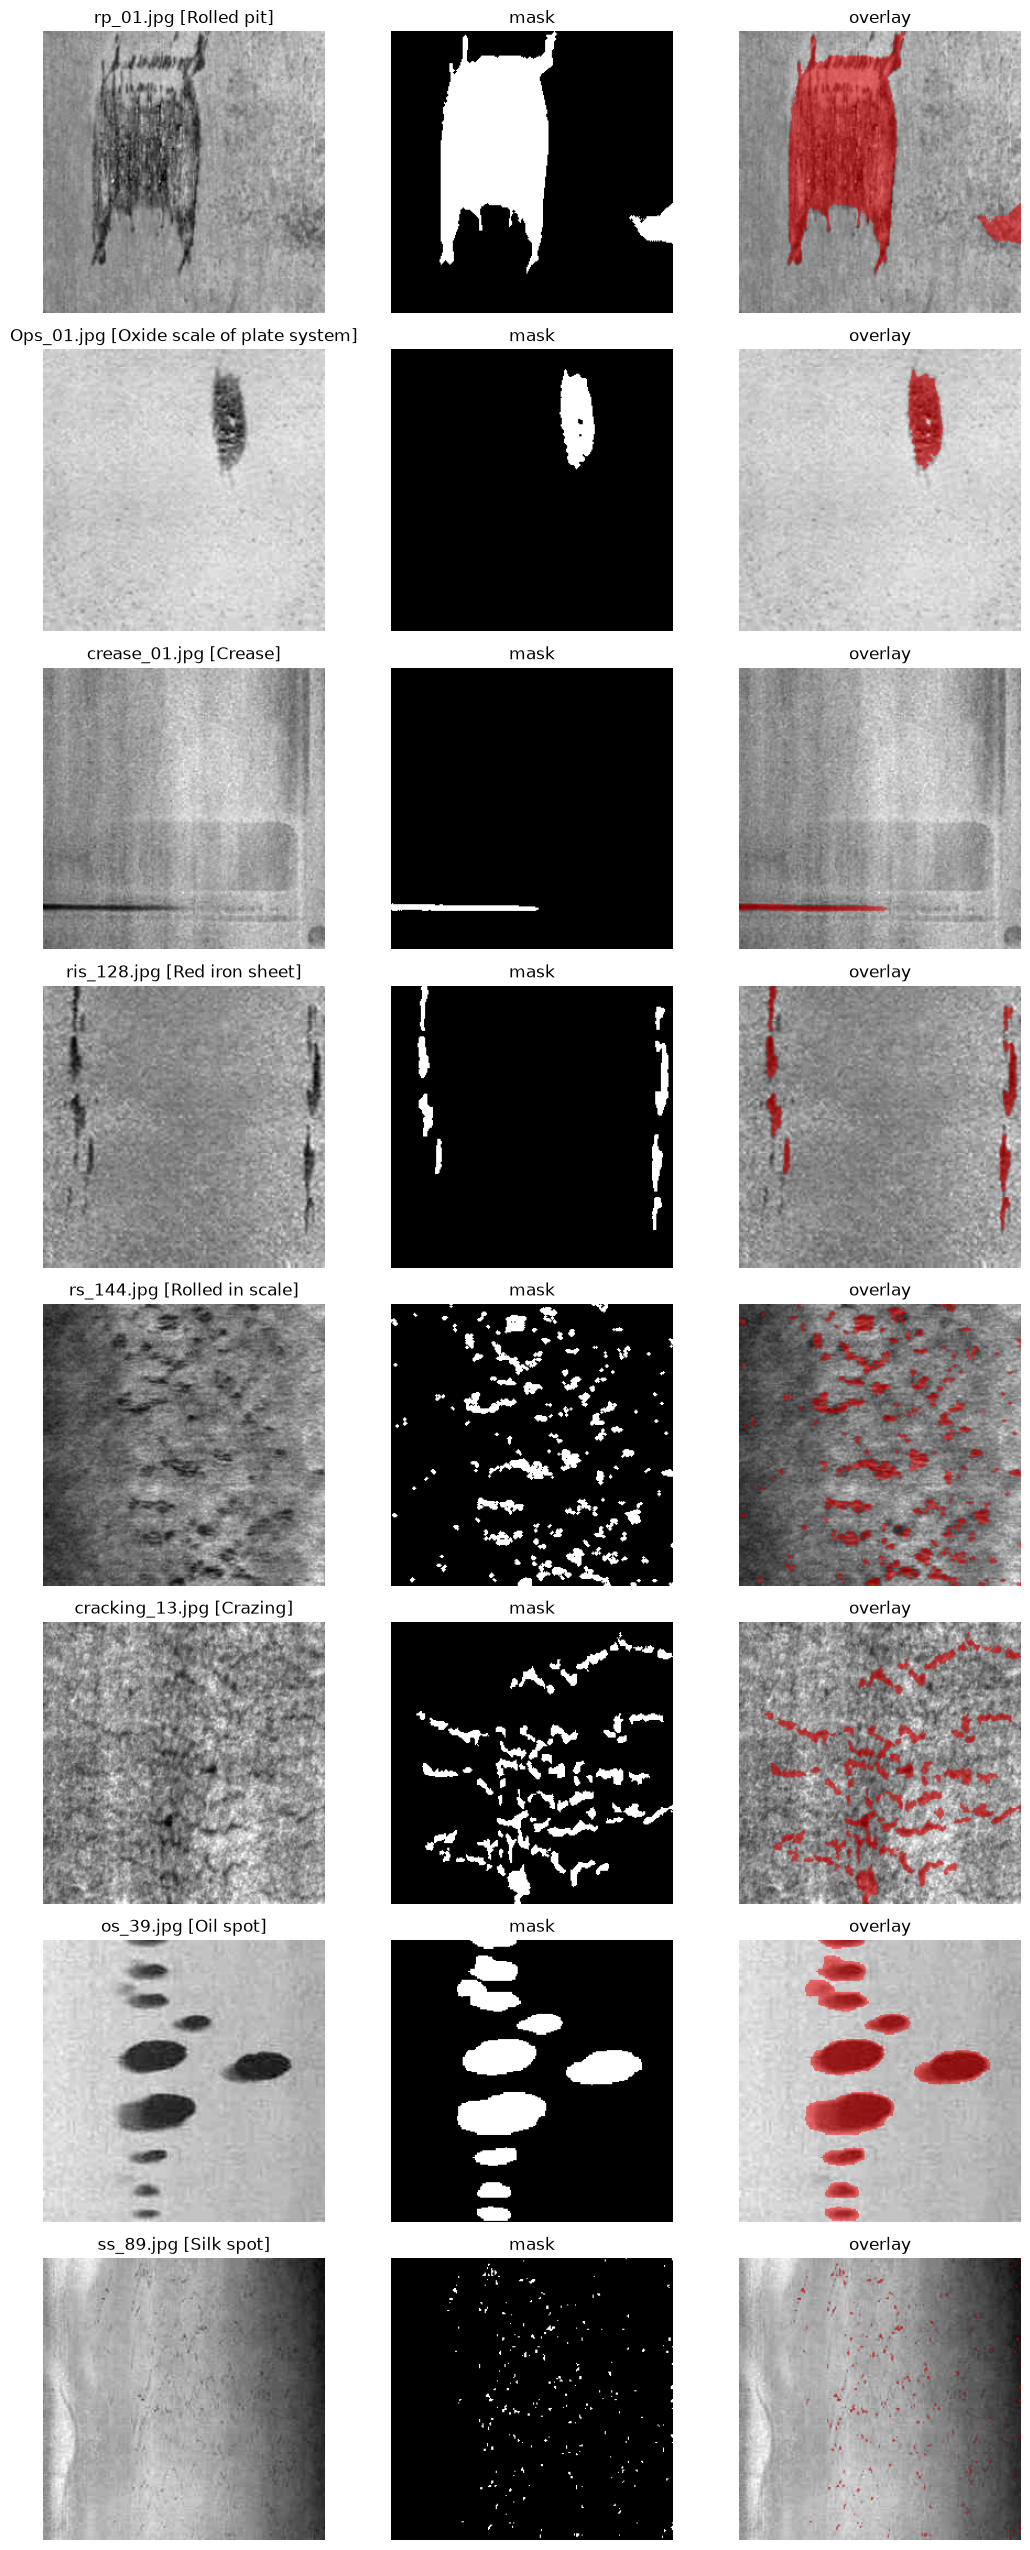

In [8]:
import matplotlib.pyplot as plt

show = pairs[:8]
fig, axes = plt.subplots(len(show), 3, figsize=(11, 3.2*len(show)))
if len(show) == 1: axes = axes[None, :]
for r, (name, cls, ip, mp) in enumerate(show):
    img  = cv2.imread(ip, cv2.IMREAD_GRAYSCALE)
    mask = (cv2.imread(mp, cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    axes[r,0].imshow(img, cmap='gray');  axes[r,0].set_title(f'{name} [{cls}]')
    axes[r,1].imshow(mask, cmap='gray');  axes[r,1].set_title('mask')
    axes[r,2].imshow(img, cmap='gray')
    axes[r,2].imshow(np.ma.masked_where(mask==0, mask), cmap='autumn', alpha=0.5)
    axes[r,2].set_title('overlay')
    for c in range(3): axes[r,c].axis('off')
plt.tight_layout(); plt.show()